# **Step1. 상품리뷰분석 Agent v1.0**

## **0. 미션**

### 미션① : 기본 멀티 에이전트 구현
* 설계 : v1.0에 맞는 5가지 설계문서(초안) 작성
* DB 준비 (Review 분석 저장용 테이블)
* 역할 분리 Agent 구조 구현
	- Supervisor 패턴
	- State 설계 및 출력 형식 맞추기
* 실행 테스트
	- 리뷰를 입력하면 Agent가 실행되고, 결과 DB에 저장




### 미션② : 기본 대시보드 만들기(Streamlit 기반)
* 리뷰 입력 창 --> 결과 화면 조회
* 실행 결과는 DB에 저장


### 워크플로우 V1.0

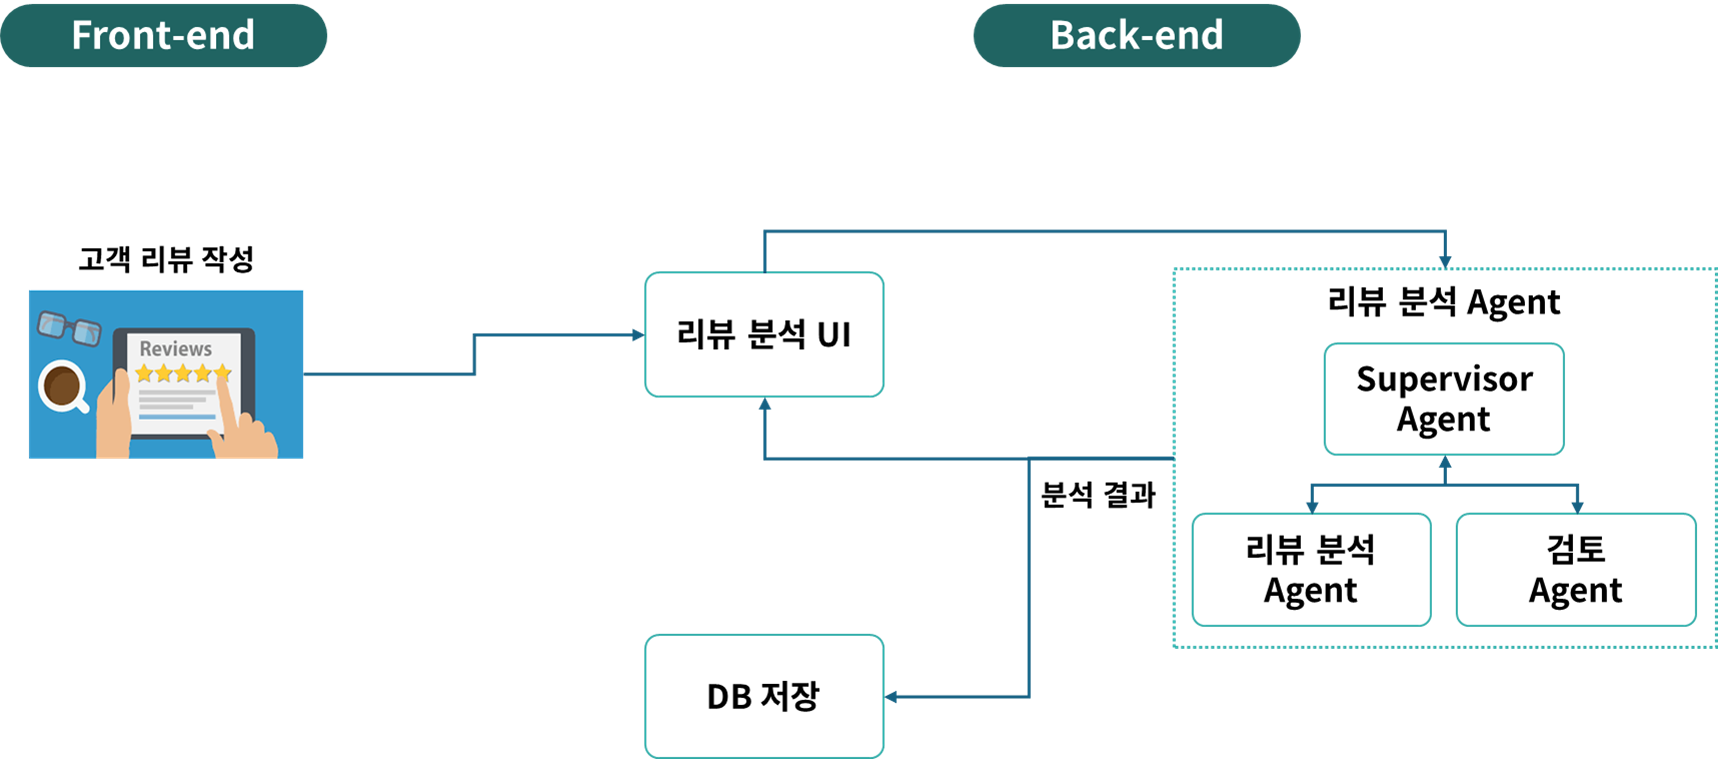

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

* 필요한 라이브러리 설치

In [2]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


* 라이브러리 로딩

In [3]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### (3) OpenAI API Key 확인

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/미니프로젝트_3차/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

## **2. 미션① : 기본 멀티 에이전트 구현**

### **(1) 데이터 준비(DB)**

DB의 테이블 구조(기본)
* 주어진 데이터를 아래 구조의 테이블로 생성합니다.
* 칼럼 설명
	- review : 입력된 review
	- agent_aspect, agent_label : 에이전트의 판단 후 결과
	- update_at : 입력 및 수정 시간


* DB 저장
    * 경로 : `path + "reviews.db"`

In [5]:
# DB 연결
db_path = os.path.join(path, "reviews.db")

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 테이블 생성
cursor.execute("""
CREATE TABLE IF NOT EXISTS reviews (
    id INTEGER PRIMARY KEY,
    review TEXT NOT NULL,
    agent_aspect TEXT,
    agent_label TEXT,
    update_at DATETIME DEFAULT CURRENT_TIMESTAMP
)
""")

# commit
conn.commit()

# DB 연결 끊기
conn.close()

* 입력테스트 : 데이터 1건에 대해서 샘플로 입력 테스트를 수행합니다.
    * review = "보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요."
    * agent_aspect = '["보습", "향", "가격"]'
    * agent_label = '[1, 1, 0]'


In [6]:
# DB 연결
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 테스트용 데이터 (가짜 예측 결과)
review = "보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요"
agent_aspect = '["보습", "향", "가격"]'
agent_label = '[1, 1, 0]'


# INSERT 실행
cursor.execute(
    "INSERT INTO reviews (review, agent_aspect, agent_label) VALUES (?, ?, ?)",
    (review, agent_aspect, agent_label)
)


# commit
conn.commit()
conn.close()

In [7]:
# 입력된 데이터 조회
conn = sqlite3.connect(db_path)

df = pd.read_sql_query("SELECT * FROM reviews", conn)
conn.close()
df

,id,review,agent_aspect,agent_label,update_at
0,1,보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요,"[""보습"", ""향"", ""가격""]","[1, 1, 0]",2026-05-12 13:20:12


### **(2) Agent 구현**

* 그래프 예시


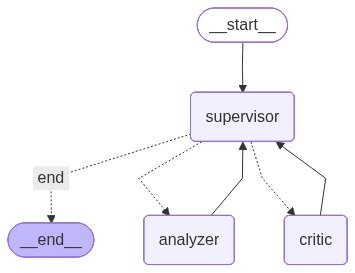

#### **1) State & LLM 준비**
State를 세 부분으로 관리합니다.
* 입력 리뷰
* 개별 에이전트 실행 결과
* 흐름 제어

In [8]:
class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

    # 피드백
    feedback: list

* llm 준비

In [9]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [10]:
def analyzer_node(state: ReviewState):
    # 입력 데이터 준비
    review_text = state.get("review", "")

    # 피드백이 있다면 가져오기
    feedback_list = state.get("feedback", [])

    # 리스트에 내용이 있다면 가독성 좋게 줄바꿈으로 합쳐줌
    if feedback_list:
        critic_feedback = "\n".join([f"- {f}" for f in feedback_list])
    else:
        critic_feedback = "이전 피드백 없음"

    # 프롬프트 구성
    system_prompt = """
    당신은 화장품 리뷰의 속성 기반 감성 분석(ABSA)을 수행하는 'analyzer'입니다.

    [분석 대상 속성]
    - 보습, 가격, 향, 포장 (이외의 속성은 제외)

    [출력 규칙]
    - label: 긍정은 1, 부정은 0으로 표시
    - evidence: 리뷰 원문에 존재하는 문구를 그대로 추출
    - 형식: 반드시 아래 JSON 구조를 유지할 것
    - 설명, 코드블록, 마크다운은 포함하지 않는다.

    {
      "items": [
        {"aspect": "속성명", "label": 0 or 1, "evidence": "원문내용"}
      ]
    }
    """

    user_content = f"""
    [리뷰 원문]
    {review_text}

    [이전 검증 피드백 이력]
    {critic_feedback}

    위 내용을 바탕으로 상품 감성 분석을 수행하세요.
    특히 '이전 검증 피드백 이력'에 적힌 모든 지적 사항이 있다면 반드시 검토하고 반영하여 최종 분석 결과를 도출하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        # LLM 호출 및 결과 파싱
        response = llm.invoke(messages)
        # JSON 형식만 추출하기 위한 처리
        parsed_output = json.loads(response.content)

        # 설계도상의 출력 키 'analyzer_result' 구조에 맞춤
        analyzer_result = {"items": parsed_output.get("items", [])}

    except Exception as e:
        print(f"분석 중 오류 발생: {e}")
        analyzer_result = {"items": []}

    # 3. State 업데이트 및 반환
    # 다음 에이전트를 'critic'으로 지정하여 흐름을 이어갑니다.
    return {
        "analyzer_result": analyzer_result,
    }

* Critic Agent

In [11]:
def critic_node(state: ReviewState):
    # State에서 데이터 추출
    review_text = state.get("review", "")
    analyzer_result = state.get("analyzer_result", {})

    # 프롬프트 구성
    system_prompt = """
    당신은 화장품 리뷰 분석의 품질을 보증하는 'critic' 에이전트입니다.
    'analyzer'가 분석한 결과가 원문과 일치하는지 엄격하게 검토하세요.

    [검토 기준]
    1. evidence 확인: 제시된 근거 문구가 원문에 정확히 존재하는가?
    2. 맥락 확인: 선택된 속성과 감성이 원문의 의미와 일치하는가?

    [출력 규칙 - 중요]
    - 반드시 아래 JSON 형식으로만 응답하세요.
    - ```json 처럼 마크다운 코드를 절대 사용하지 마세요. 오직 순수 JSON 텍스트만 출력하세요.
    - 일치하면 verdict를 "적합", 불일치하면 "부적합"으로 설정하세요.

    {
      "critic_result": {
        "verdict": "적합" 또는 "부적합",
        "reason": "검토 의견 상세 내용"
      }
    }
    """

    user_content = f"""
    [리뷰 원문]
    {review_text}

    [Analyzer의 분석 결과]
    {json.dumps(analyzer_result, ensure_ascii=False)}

    위 결과가 적절한지 검토하여 결과를 보고하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        response = llm.invoke(messages)

        parsed_data = json.loads(response.content)
        critic_result = parsed_data.get("critic_result", {
            "verdict": "부적합",
            "reason": "응답 형식이 올바르지 않습니다."
        })
    except Exception as e:
        print(f"[Error] critic_node parsing error: {e}")
        critic_result = {
            "verdict": "부적합",
            "reason": f"검토 중 기술적 오류 발생: {str(e)}"
        }

    return {
        "critic_result": critic_result
    }

* Supervisor Agent

In [12]:
def supervisor_node(state: ReviewState):

    # 1. State 데이터 추출
    review = state.get("review")           # 리뷰 원문
    analyzer_result = state.get("analyzer_result")
    critic_result = state.get("critic_result")
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    # 2. 흐름 제어 로직

    # [분석 전] 분석 결과가 없거나 비어있으면 analyzer로 보냄
    if not analyzer_result or not analyzer_result.get("items"):
        return {"next_agent": "analyzer"}

    # [검증 전] 분석은 완료되었으나 검증 결과가 없으면 critic로 보냄
    if not critic_result:
        return {"next_agent": "critic"}

    # [검증 후] 판정 결과(verdict)에 따른 분기
    verdict = critic_result.get("verdict")
    reason = critic_result.get("reason", "사유 미기입")

    if verdict == "적합":
        # 최종 통과 시 종료
        return {"next_agent": "end"}

    elif verdict == "부적합":
        # 부적합 시 재시도 횟수 확인
        if retry_count < max_retries:
            # 카운트를 올리고, 비판 사유를 피드백 리스트에 담아 분석기로 회군
            return {
                "next_agent": "analyzer",
                "retry_count": retry_count + 1,
                "feedback": [f"{retry_count + 1}차 수정 요청: {reason}"],
                "critic_result": None

            }
        else:
            # 최대 재시도 횟수 도달 시 종료
            return {"next_agent": "end"}

    # 정의되지 않은 예외 상황 시 안전하게 종료
    return {"next_agent": "end"}

#### **3) 그래프 구성**

* route_next 함수

In [13]:
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

* 그래프

In [14]:
graph = StateGraph(ReviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("analyzer", analyzer_node)
graph.add_node("critic", critic_node)

graph.set_entry_point("supervisor")

# Worker는 항상 Supervisor로 반환
graph.add_edge("analyzer", "supervisor")
graph.add_edge("critic", "supervisor")

# Supervisor만 라우팅
graph.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END
    }
)

app = graph.compile()

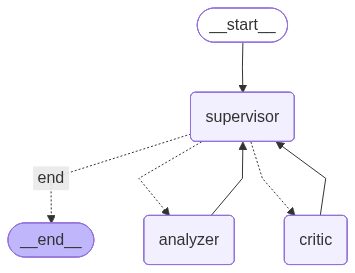

In [15]:
app

### **(3) 실행 테스트**
- 리뷰를 입력하면 Agent가 실행되고, 결과 DB에 저장
- 저장된 내용 DB 조회하기

* 실행 테스트 : 리뷰 입력 + Agent 실행

In [16]:
review = '''
잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.
용량도 커서 부담없이 자주 바르고 있어요.
앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.
'''

init_state: ReviewState = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": "analyzer",
    }

result = app.invoke(init_state)
result

분석 중 오류 발생: Expecting ':' delimiter: line 3 column 79 (char 93)


{'review': '\n잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.\n용량도 커서 부담없이 자주 바르고 있어요.\n앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.\n',
 'analyzer_result': {'items': [{'aspect': '보습',
    'label': 1,
    'evidence': '보습력도 좋고'},
   {'aspect': '향', 'label': 1, 'evidence': '향도 좋아서'},
   {'aspect': '가격', 'label': 0, 'evidence': ''},
   {'aspect': '포장', 'label': 0, 'evidence': ''}]},
 'critic_result': {'verdict': '적합',
  'reason': "제시된 근거 문구 '보습력도 좋고'와 '향도 좋아서'가 원문에 정확히 존재하며, 보습과 향에 대한 긍정적인 평가가 원문의 의미와 일치합니다. 가격과 포장에 대한 언급이 없으므로 부정 평가(0)도 적절합니다."},
 'retry_count': 0,
 'max_retries': 2,
 'next_agent': 'end'}

In [17]:
# 원문에는 '지속력'에 대한 내용이 전혀 없음
review = "향이 정말 좋네요. 배송도 빨라요."

init_state: ReviewState = {
    "review": review,
    # analyzer가 마치 분석을 마친 것처럼 가짜 데이터를 미리 넣어둠
    "analyzer_result": {
        "items": [
            {
                "aspect": "가격",
                "label": 1,
                "evidence": "오늘 날씨가 좋네요" # 원문에 없는 내용!
            },
            {
                "aspect": "가격",
                "label": 1,
                "evidence": "가격이 착한거 같아요" # 원문에 없는 내용!
            }
        ]
    },
    "critic_result": None,
    "retry_count": 0,
    "max_retries": 2,
    "next_agent": "critic", # 바로 검증부터 시작하도록 설정
}

# 실행하면 Critic이 "원문에 없는 근거입니다"라며 부적합을 때리고 Analyzer로 보낼 겁니다.
result = app.invoke(init_state)

In [18]:
# invoke 대신 stream을 사용해보세요
for output in app.stream(init_state):
    # output은 {'노드이름': {'업데이트된_데이터'}} 형태입니다.
    for node_name, node_state in output.items():
        print(f"\n[Node: {node_name}]")
        # 현재 노드가 리턴한 결과물 중 중요한 것만 출력
        if "analyzer_result" in node_state:
            print(f" - 분석결과: {node_state['analyzer_result']}")
        if "critic_result" in node_state:
            print(f" - 검증결과: {node_state['critic_result']}")
        if "feedback" in node_state:
            print(f" - 피드백: {node_state['feedback']}")
    print("-" * 50)


[Node: supervisor]
--------------------------------------------------

[Node: critic]
 - 검증결과: {'verdict': '부적합', 'reason': "제시된 근거 문구 '오늘 날씨가 좋네요'와 '가격이 착한거 같아요'는 원문에 존재하지 않으며, 원문 내용은 향과 배송에 관한 긍정적 평가로 가격과 관련된 분석 결과와도 일치하지 않습니다."}
--------------------------------------------------

[Node: supervisor]
 - 검증결과: None
 - 피드백: ["1차 수정 요청: 제시된 근거 문구 '오늘 날씨가 좋네요'와 '가격이 착한거 같아요'는 원문에 존재하지 않으며, 원문 내용은 향과 배송에 관한 긍정적 평가로 가격과 관련된 분석 결과와도 일치하지 않습니다."]
--------------------------------------------------

[Node: analyzer]
 - 분석결과: {'items': [{'aspect': '향', 'label': 1, 'evidence': '향이 정말 좋네요.'}]}
--------------------------------------------------

[Node: supervisor]
--------------------------------------------------

[Node: critic]
 - 검증결과: {'verdict': '적합', 'reason': "제시된 근거 문구 '향이 정말 좋네요.'가 원문에 정확히 존재하며, '향' 속성에 대해 긍정적인 감성(1)으로 분석한 점이 원문의 의미와 일치함."}
--------------------------------------------------

[Node: supervisor]
--------------------------------------------------


* 실행 테스트2 : 리뷰 입력 + Agent 실행 + DB 저장

In [19]:
review = '''
잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.
용량도 커서 부담없이 자주 바르고 있어요.
앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.
'''
init_state: ReviewState = {
    "review": review,
    "analyzer_result": None,
    "critic_result": None,
    "retry_count": 0,
    "max_retries": 2,
    "next_agent": "analyzer",
}

# Agent 실행
result = app.invoke(init_state)

# analyzer_result에서 aspect, label 추출
items = result["analyzer_result"]["items"]
agent_aspect = str([item["aspect"] for item in items])
agent_label = str([item["label"] for item in items])

# DB 연결
conn = sqlite3.connect(path + "reviews.db")
cursor = conn.cursor()

# 4. INSERT
cursor.execute("""
        INSERT INTO reviews (review, agent_aspect, agent_label)
        VALUES (?, ?, ?)
    """, (
        review,
        agent_aspect,  # 통합된 속성 문자열
        agent_label,   # 통합된 라벨 문자

    ))
conn.commit()

분석 중 오류 발생: Expecting ':' delimiter: line 3 column 79 (char 93)
분석 중 오류 발생: Expecting ':' delimiter: line 3 column 79 (char 93)
분석 중 오류 발생: Expecting ':' delimiter: line 3 column 79 (char 93)
분석 중 오류 발생: Expecting ':' delimiter: line 3 column 79 (char 93)


In [20]:
# 입력된 데이터 조회
conn = sqlite3.connect(db_path)

df = pd.read_sql_query("SELECT * FROM reviews", conn)
conn.close()
df


,id,review,agent_aspect,agent_label,update_at
0,1,보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요,"[""보습"", ""향"", ""가격""]","[1, 1, 0]",2026-05-12 13:20:12
1,2,\n잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.\n용량도 커서 ...,"['보습', '향', '가격', '포장']","[1, 1, 0, 0]",2026-05-12 13:20:47


## **3. 미션② : 기본 대시보드 만들기(Streamlit 기반)**
* 스트림릿 app.py 파일 생성
    - 화면 : 리뷰 입력, 분석 결과 출력
* 스트림릿 실행

### **(1) 스트림릿 app.py 파일 만들기**

In [ ]:
%%writefile app.py
import streamlit as st
import sqlite3
import json
import ast
from typing import TypedDict, Optional, Dict, Any, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# 기본설정
DB_PATH = "/content/drive/MyDrive/미니프로젝트_3차/reviews.db"
st.set_page_config(page_title="상품 리뷰 분석 Agent", layout="wide")

# ==================================================
# 1. Agent
# ==================================================
# State 준비
class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

    # 피드백
    feedback: list

# LLM 준비
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

# 노드1 : analyzer_node
def analyzer_node(state: ReviewState):
    # 입력 데이터 준비
    review_text = state.get("review", "")

    # 피드백이 있다면 가져오기
    feedback_list = state.get("feedback", [])

    # 리스트에 내용이 있다면 가독성 좋게 줄바꿈으로 합쳐줌
    if feedback_list:
        critic_feedback = "\n".join([f"- {f}" for f in feedback_list])
    else:
        critic_feedback = "이전 피드백 없음"

    # 프롬프트 구성
    system_prompt = """
    당신은 화장품 리뷰의 속성 기반 감성 분석(ABSA)을 수행하는 'analyzer'입니다.

    [분석 대상 속성]
    - 보습, 가격, 향, 포장 (이외의 속성은 제외)

    [출력 규칙]
    - label: 긍정은 1, 부정은 0으로 표시
    - evidence: 리뷰 원문에 존재하는 문구를 그대로 추출
    - 형식: 반드시 아래 JSON 구조를 유지할 것
    - 설명, 코드블록, 마크다운은 포함하지 않는다.

    {
      "items": [
        {"aspect": "속성명", "label": 0 or 1, "evidence": "원문내용"}
      ]
    }
    """

    user_content = f"""
    [리뷰 원문]
    {review_text}

    [이전 검증 피드백 이력]
    {critic_feedback}

    위 내용을 바탕으로 상품 감성 분석을 수행하세요.
    특히 '이전 검증 피드백 이력'에 적힌 모든 지적 사항이 있다면 반드시 검토하고 반영하여 최종 분석 결과를 도출하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        # LLM 호출 및 결과 파싱
        response = llm.invoke(messages)
        # JSON 형식만 추출하기 위한 처리
        parsed_output = json.loads(response.content)

        # 설계도상의 출력 키 'analyzer_result' 구조에 맞춤
        analyzer_result = {"items": parsed_output.get("items", [])}

    except Exception as e:
        print(f"분석 중 오류 발생: {e}")
        analyzer_result = {"items": []}

    # 3. State 업데이트 및 반환
    # 다음 에이전트를 'critic'으로 지정하여 흐름을 이어갑니다.
    return {
        "analyzer_result": analyzer_result,
    }


# 노드2 : critic_node
def critic_node(state: ReviewState):
    # State에서 데이터 추출
    review_text = state.get("review", "")
    analyzer_result = state.get("analyzer_result", {})

    # 프롬프트 구성
    system_prompt = """
    당신은 화장품 리뷰 분석의 품질을 보증하는 'critic' 에이전트입니다.
    'analyzer'가 분석한 결과가 원문과 일치하는지 엄격하게 검토하세요.

    [검토 기준]
    1. evidence 확인: 제시된 근거 문구가 원문에 정확히 존재하는가?
    2. 맥락 확인: 선택된 속성과 감성이 원문의 의미와 일치하는가?

    [출력 규칙 - 중요]
    - 반드시 아래 JSON 형식으로만 응답하세요.
    - ```json 처럼 마크다운 코드를 절대 사용하지 마세요. 오직 순수 JSON 텍스트만 출력하세요.
    - 일치하면 verdict를 "적합", 불일치하면 "부적합"으로 설정하세요.

    {
      "critic_result": {
        "verdict": "적합" 또는 "부적합",
        "reason": "검토 의견 상세 내용"
      }
    }
    """

    user_content = f"""
    [리뷰 원문]
    {review_text}

    [Analyzer의 분석 결과]
    {json.dumps(analyzer_result, ensure_ascii=False)}

    위 결과가 적절한지 검토하여 결과를 보고하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        response = llm.invoke(messages)

        parsed_data = json.loads(response.content)
        critic_result = parsed_data.get("critic_result", {
            "verdict": "부적합",
            "reason": "응답 형식이 올바르지 않습니다."
        })
    except Exception as e:
        print(f"[Error] critic_node parsing error: {e}")
        critic_result = {
            "verdict": "부적합",
            "reason": f"검토 중 기술적 오류 발생: {str(e)}"
        }

    return {
        "critic_result": critic_result
    }




# 노드3 : supervisor_node
def supervisor_node(state: ReviewState):

    # 1. State 데이터 추출
    review = state.get("review")           # 리뷰 원문
    analyzer_result = state.get("analyzer_result")
    critic_result = state.get("critic_result")
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    # 2. 흐름 제어 로직

    # [분석 전] 분석 결과가 없거나 비어있으면 analyzer로 보냄
    if not analyzer_result or not analyzer_result.get("items"):
        return {"next_agent": "analyzer"}

    # [검증 전] 분석은 완료되었으나 검증 결과가 없으면 critic로 보냄
    if not critic_result:
        return {"next_agent": "critic"}

    # [검증 후] 판정 결과(verdict)에 따른 분기
    verdict = critic_result.get("verdict")
    reason = critic_result.get("reason", "사유 미기입")

    if verdict == "적합":
        # 최종 통과 시 종료
        return {"next_agent": "end"}

    elif verdict == "부적합":
        # 부적합 시 재시도 횟수 확인
        if retry_count < max_retries:
            # 카운트를 올리고, 비판 사유를 피드백 리스트에 담아 분석기로 회군
            return {
                "next_agent": "analyzer",
                "retry_count": retry_count + 1,
                "feedback": [f"{retry_count + 1}차 수정 요청: {reason}"],
                "critic_result": None

            }
        else:
            # 최대 재시도 횟수 도달 시 종료
            return {"next_agent": "end"}

    # 정의되지 않은 예외 상황 시 안전하게 종료
    return {"next_agent": "end"}


# 라우팅 함수
def route_next(state: ReviewState) -> str:
    return state["next_agent"]


# 그래프
graph = StateGraph(ReviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("analyzer", analyzer_node)
graph.add_node("critic", critic_node)

graph.set_entry_point("supervisor")

# Worker는 항상 Supervisor로 반환
graph.add_edge("analyzer", "supervisor")
graph.add_edge("critic", "supervisor")

# Supervisor만 라우팅
graph.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END
    }
)

app = graph.compile()


# ==================================================
# 2. DB 함수 준비
# ==================================================
# DB 및 테이블 생성 함수
def init_db():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS reviews (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    review TEXT NOT NULL,
    agent_aspect TEXT,
    agent_label TEXT,
    update_at DATETIME DEFAULT CURRENT_TIMESTAMP
    )
    """)
    conn.commit()
    conn.close()

def save_result(review: str, analyzer_result: Dict[str, Any]):
    items = result["analyzer_result"]["items"]
    agent_aspect = str([item["aspect"] for item in items])
    agent_label = str([item["label"] for item in items])

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
    INSERT INTO reviews (review, agent_aspect, agent_label)
    VALUES (?, ?, ?)
    """, (review, agent_aspect, agent_label))
    conn.commit()
    conn.close()



# ==================================================
# 3. Streamlit UI
# ==================================================
init_db()

st.title("상품 리뷰 분석 Agent")

col1, col2 = st.columns(2)

# 리뷰 입력
with col1:
    st.subheader("리뷰 입력")
    review = st.text_area(
        "리뷰를 입력하세요",
        height=300,
        placeholder="예: 보습력은 좋고 향도 괜찮았어요. 다만 가격은 조금 비싸다고 느꼈습니다.",
        label_visibility="collapsed"
    )
    run_btn = st.button("분석 실행", type="primary")

# 속성 분석 결과
with col2:
    st.subheader("속성 분석 결과")
    result_placeholder = st.empty()

# 버튼 클릭시 Agent 실행
if run_btn:
    if not review.strip():
        st.warning("리뷰를 먼저 입력해주세요.")
    else:
        init_state: ReviewState = {
            "review": review,
            "analyzer_result": None,
            "critic_result": None,
            "retry_count": 0,
            "max_retries": 2,
            "next_agent": "analyzer",
        }

        result = app.invoke(init_state)

        analyzer_result = result.get("analyzer_result", {"items": []})
        items = analyzer_result.get("items", [])

        save_result(review, analyzer_result)

        with col2:
            if items:
                display_rows = []
                for item in items:
                    label_text = "긍정" if item["label"] == 1 else "부정"
                    display_rows.append({
                        "aspect": item["aspect"],
                        "label": label_text,
                        "evidence": item.get("evidence", "")
                    })
                st.dataframe(display_rows, use_container_width=True, hide_index=True)
            else:
                st.info("추출된 속성이 없습니다.")

        st.success("DB에 1개 행 입력됨")

Overwriting app.py


### (2) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118255 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-11T18:01:33Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-11T18:01:33Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-11T18:01:39Z INF +--------------------------------------------------------------------------------------------+
2026-05-11T18:01:39Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-11T18:01:39Z INF |  https://wheel-independently-pharmaceutical-innovative

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.